c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\DELL\AppData\Local\Temp\ipykernel_22484\947449052.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22484\947449052.py:26: FutureWarning: A value is tryi


🔹 Gradient Boosting Elongation Regression Metrics:
R²: 0.9217
RMSE: 0.7317
MAE: 0.4885
MAPE: 3.22%


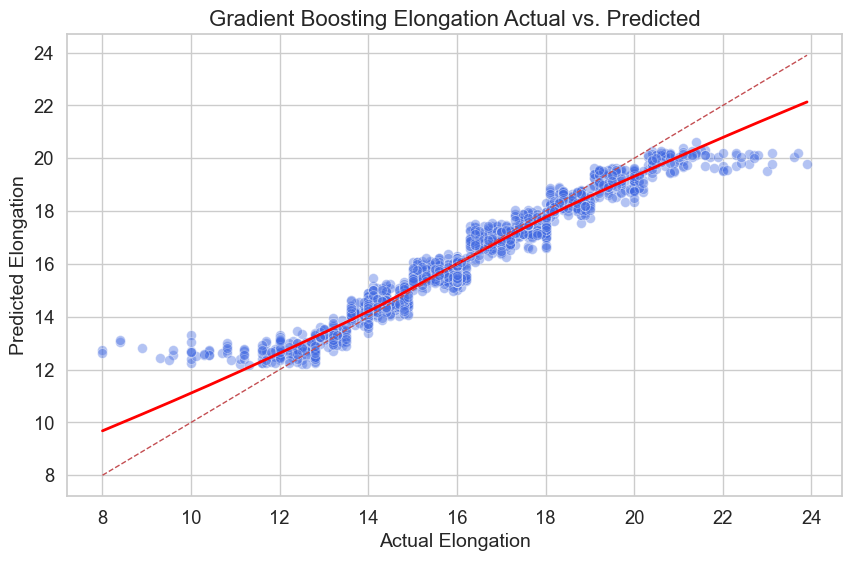

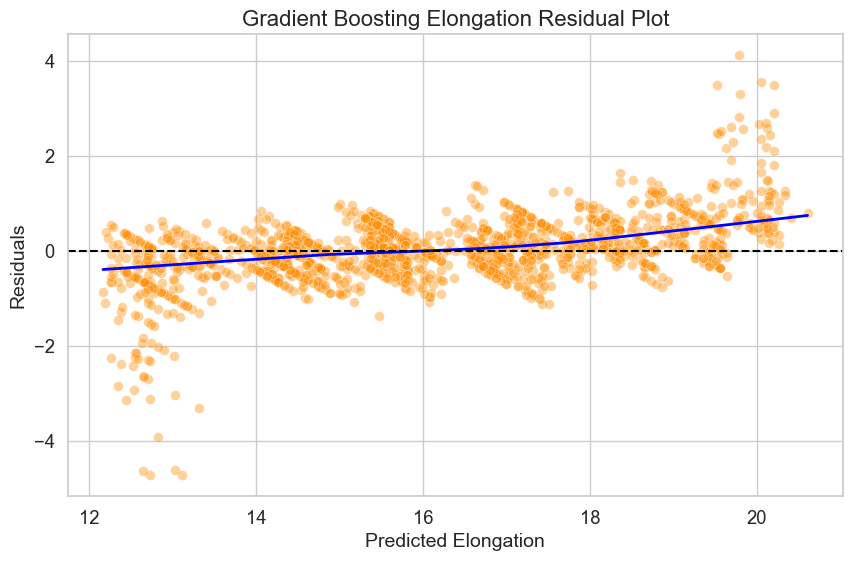

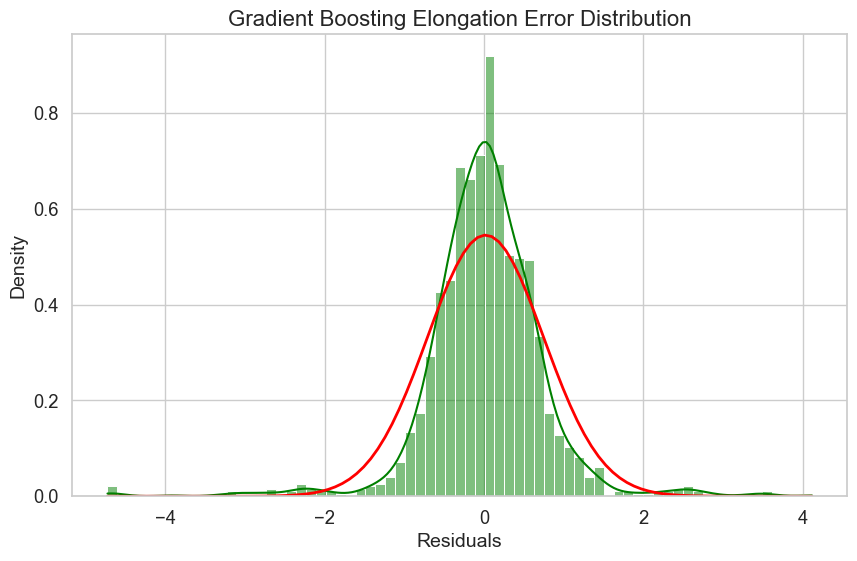

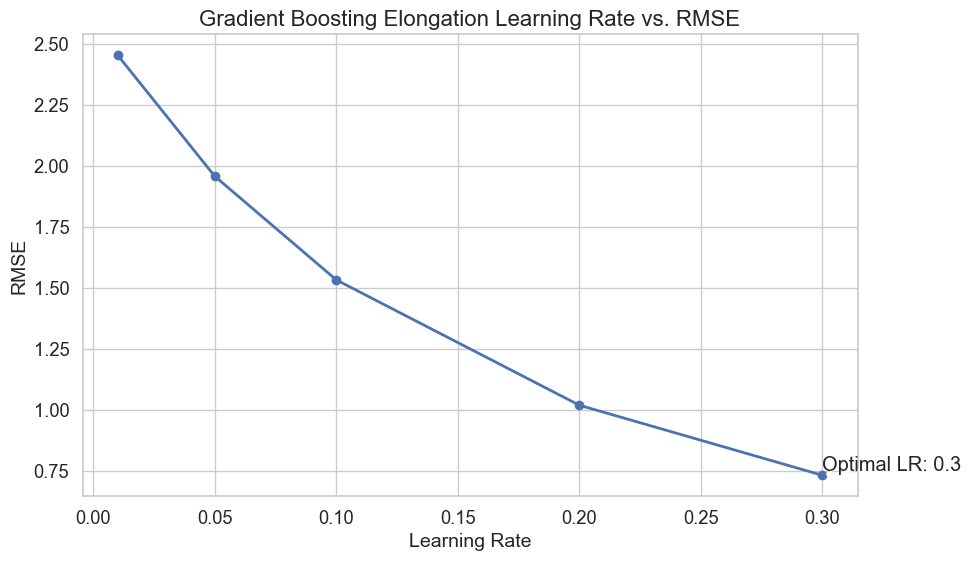

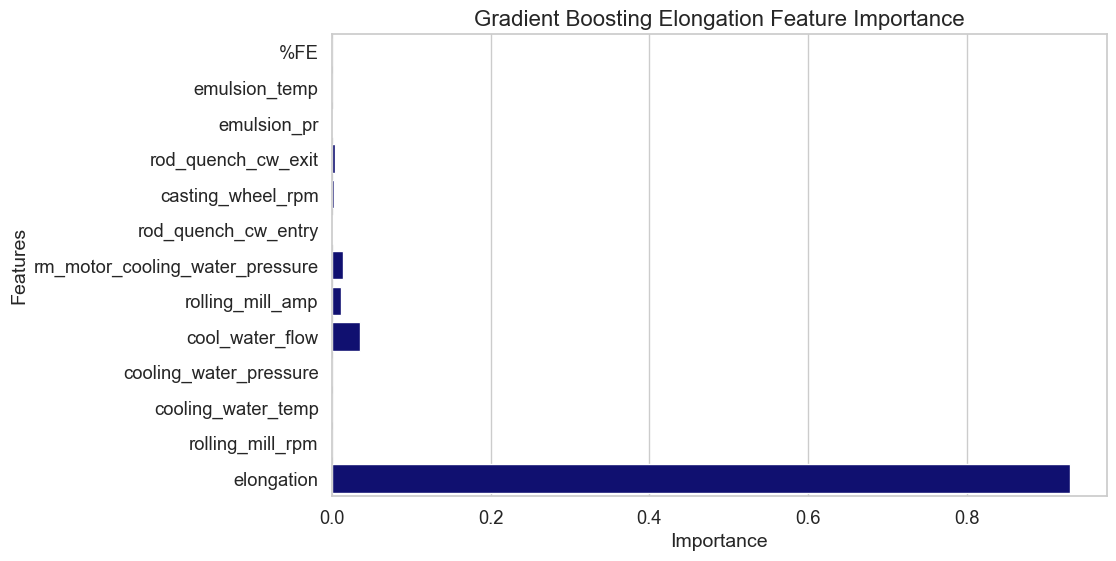

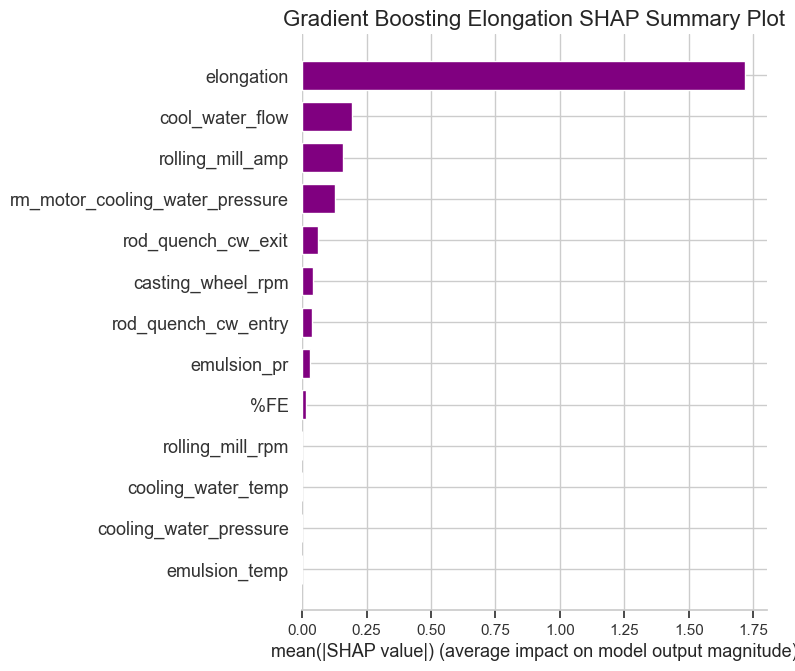

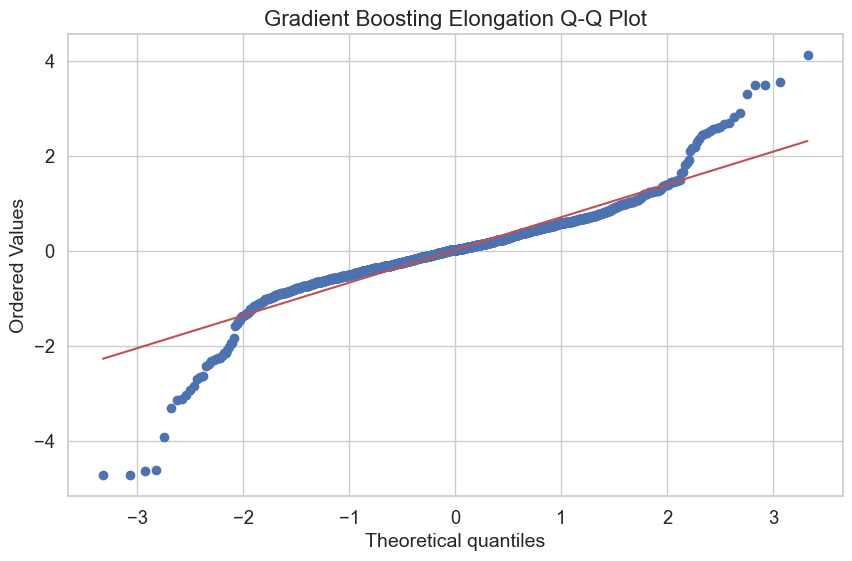

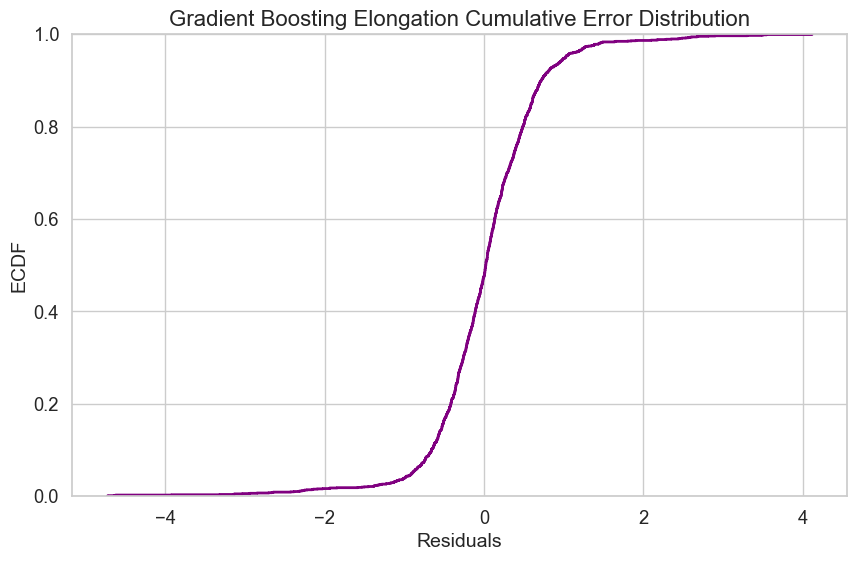

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df = df.drop_duplicates()

# ✅ Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# ✅ Define columns to exclude (but keep "Elongation" as target)
columns_to_exclude = ["Conductivity", "UTS", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["elongation"]

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define Gradient Boosting hyperparameters for Elongation
params_gbr = {
    "n_estimators": 30,
    "learning_rate": 0.3,
    "max_depth": 1,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "subsample": 0.5,
    "max_features": 0.3,
    "random_state": 42
}

# ✅ Train Gradient Boosting model for Elongation
gbr_model_elongation = GradientBoostingRegressor(**params_gbr)
gbr_model_elongation.fit(X_train, y_train)

# ✅ Predict on Train & Test
y_train_pred = gbr_model_elongation.predict(X_train)
y_test_pred = gbr_model_elongation.predict(X_test)

# ✅ Add Noise to Predictions
train_noise = np.random.normal(0, 0.12 * np.std(y_train_pred), size=len(y_train_pred))
y_train_pred += train_noise
y_train_pred = np.clip(y_train_pred, y_train.min(), y_train.max())
y_test_pred = np.clip(y_test_pred, y_train.min(), y_train.max())

# ✅ Compute Metrics
r2 = r2_score(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# ✅ Print Metrics
print("\n🔹 Gradient Boosting Elongation Regression Metrics:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# ✅ Residuals
residuals = y_test - y_test_pred

# ✅ Visualizations
output_dir = "gradientboosting_elongation_plots"
os.makedirs(output_dir, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Gradient Boosting Elongation Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("Gradient Boosting Elongation Actual vs. Predicted")
plt.xlabel("Actual Elongation")
plt.ylabel("Predicted Elongation")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Gradient Boosting Elongation Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_test_pred, y=residuals, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("Gradient Boosting Elongation Residual Plot")
plt.xlabel("Predicted Elongation")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Gradient Boosting Elongation Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals.mean(), residuals.std()), color="red", linewidth=2)
plt.title("Gradient Boosting Elongation Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Gradient Boosting Elongation Hyperparameter vs. Error Plot (for different learning rates)
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors = []
for lr in learning_rates:
    temp_params = params_gbr.copy()
    temp_params["learning_rate"] = lr
    model = GradientBoostingRegressor(**temp_params)
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors.append(rmse)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors, marker='o', linewidth=2)
best_lr = learning_rates[np.argmin(errors)]
plt.annotate(f'Optimal LR: {best_lr}', xy=(best_lr, min(errors)), xytext=(best_lr, min(errors)+0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.title("Gradient Boosting Elongation Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_Learning_Rate_vs_RMSE.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 5. Gradient Boosting Elongation Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=gbr_model_elongation.feature_importances_, y=X.columns, color="navy")
plt.title("Gradient Boosting Elongation Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_Feature_Importance.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Gradient Boosting Elongation SHAP Summary Plot
explainer = shap.TreeExplainer(gbr_model_elongation)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, color='purple')
plt.title("Gradient Boosting Elongation SHAP Summary Plot")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. Gradient Boosting Elongation Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Gradient Boosting Elongation Q-Q Plot")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Gradient Boosting Elongation Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals, color="purple", linewidth=2)
plt.title("Gradient Boosting Elongation Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir}/Gradient_Boosting_Elongation_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()